In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
    roc_curve,
)

DATA_DIR = Path("../data/paper_final_splits")
RANDOM_STATE = 20240627
N_SPLITS = 5

TASKS = {
    "before_mask": "Before mandate - Face mask",
    "after_mask": "After mandate - Face mask",
    "before_protective": "Before mandate - Protective behaviour",
    "after_protective": "After mandate - Protective behaviour",
}

METRICS = ["precision", "recall", "roc_auc", "accuracy", "f1"]


def load_task(task):
    X_train = pd.read_csv(DATA_DIR / f"X_train_{task}.csv")
    X_test = pd.read_csv(DATA_DIR / f"X_test_{task}.csv")
    y_train = pd.read_csv(DATA_DIR / f"y_train_{task}.csv").iloc[:, 0].astype(int)
    y_test = pd.read_csv(DATA_DIR / f"y_test_{task}.csv").iloc[:, 0].astype(int)
    return X_train, X_test, y_train, y_test


def upsample(X, y, seed):
    ros = RandomOverSampler(random_state=seed)
    X_up, y_up = ros.fit_resample(X, y)
    return X_up, pd.Series(y_up)


def build_model():
    return LogisticRegression(max_iter=5000, solver="liblinear", random_state=RANDOM_STATE)


def get_metrics(y_true, y_pred, y_prob):
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


results = {}
cv_summary = []
test_summary = []

for task, label in TASKS.items():
    X_train, X_test, y_train, y_test = load_task(task)

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    cv_rows = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        X_tr_up, y_tr_up = upsample(X_tr, y_tr, RANDOM_STATE + fold)

        model = build_model()
        model.fit(X_tr_up, y_tr_up)

        y_val_pred = model.predict(X_val)
        y_val_prob = model.predict_proba(X_val)[:, 1]

        row = get_metrics(y_val, y_val_pred, y_val_prob)
        row["fold"] = fold
        cv_rows.append(row)

    cv_df = pd.DataFrame(cv_rows)
    cv_mean = cv_df[METRICS].mean().to_dict()
    cv_mean["task"] = task
    cv_mean["label"] = label
    cv_summary.append(cv_mean)

    X_train_up, y_train_up = upsample(X_train, y_train, RANDOM_STATE)
    final_model = build_model()
    final_model.fit(X_train_up, y_train_up)

    y_test_pred = final_model.predict(X_test)
    y_test_prob = final_model.predict_proba(X_test)[:, 1]

    test_row = get_metrics(y_test, y_test_pred, y_test_prob)
    test_row["task"] = task
    test_row["label"] = label
    test_summary.append(test_row)

    coef_df = pd.DataFrame({
        "feature": X_train.columns,
        "coefficient": final_model.coef_[0],
        "abs_coefficient": np.abs(final_model.coef_[0])
    }).sort_values("abs_coefficient", ascending=False)

    results[task] = {
        "label": label,
        "cv_df": cv_df,
        "test_metrics": test_row,
        "y_test": y_test,
        "y_test_pred": y_test_pred,
        "y_test_prob": y_test_prob,
        "coef_df": coef_df,
        "cm": confusion_matrix(y_test, y_test_pred)
    }

cv_summary_df = pd.DataFrame(cv_summary)[["task", "label"] + METRICS]
test_summary_df = pd.DataFrame(test_summary)[["task", "label"] + METRICS]

print("CV mean results")
display(cv_summary_df.round(4))

print("Test results")
display(test_summary_df.round(4))



OUTPUT_DIR = Path("../data/model_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
cv_summary_df.to_csv(OUTPUT_DIR / "logistic_regression_cv_summary.csv", index=False)
test_summary_df.to_csv(OUTPUT_DIR / "logistic_regression_test_summary.csv", index=False)



CV mean results


,task,label,precision,recall,roc_auc,accuracy,f1
0,before_mask,Before mandate - Face mask,0.4841,0.7614,0.8208,0.7288,0.5918
1,after_mask,After mandate - Face mask,0.8796,0.7799,0.8343,0.7691,0.8267
2,before_protective,Before mandate - Protective behaviour,0.6879,0.6964,0.7327,0.6720,0.6921
3,after_protective,After mandate - Protective behaviour,0.8609,0.7308,0.7851,0.7195,0.7905


Test results


,task,label,precision,recall,roc_auc,accuracy,f1
0,before_mask,Before mandate - Face mask,0.4771,0.7409,0.8151,0.7233,0.5804
1,after_mask,After mandate - Face mask,0.8702,0.7758,0.8302,0.7599,0.8203
2,before_protective,Before mandate - Protective behaviour,0.6814,0.6896,0.7292,0.6651,0.6855
3,after_protective,After mandate - Protective behaviour,0.8567,0.7341,0.7736,0.7186,0.7907


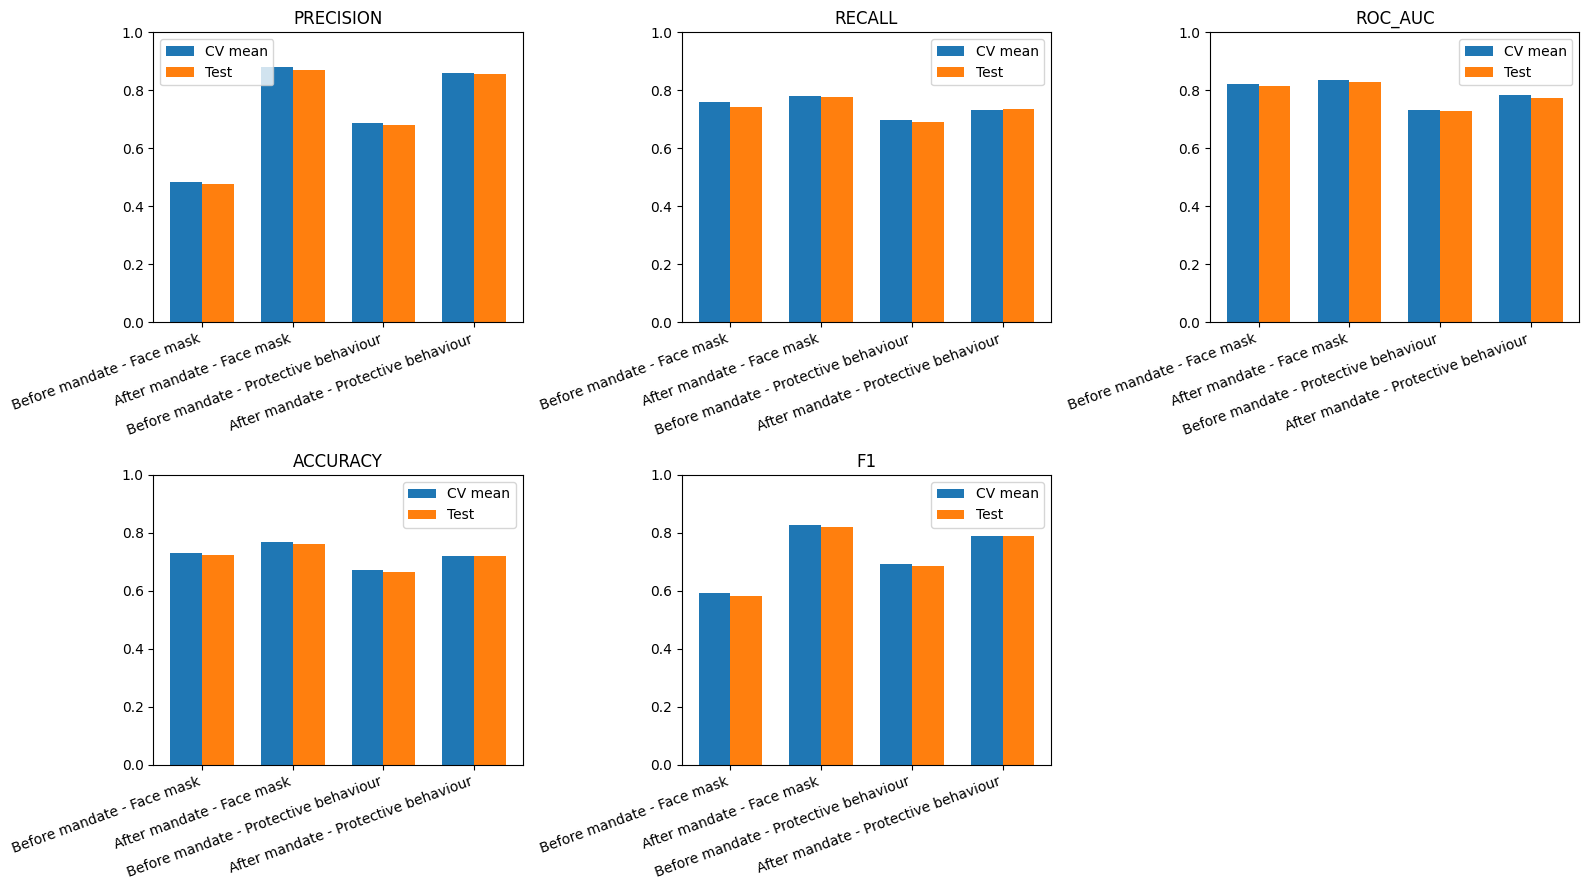

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, metric in enumerate(METRICS):
    ax = axes[i]
    cv_vals = cv_summary_df.set_index("task").loc[list(TASKS.keys()), metric]
    test_vals = test_summary_df.set_index("task").loc[list(TASKS.keys()), metric]

    x = np.arange(len(TASKS))
    width = 0.35

    ax.bar(x - width/2, cv_vals.values, width=width, label="CV mean")
    ax.bar(x + width/2, test_vals.values, width=width, label="Test")
    ax.set_xticks(x)
    ax.set_xticklabels(list(TASKS.values()), rotation=20, ha="right")
    ax.set_ylim(0, 1)
    ax.set_title(metric.upper())
    ax.legend()

axes[-1].axis("off")
plt.tight_layout()
plt.show()


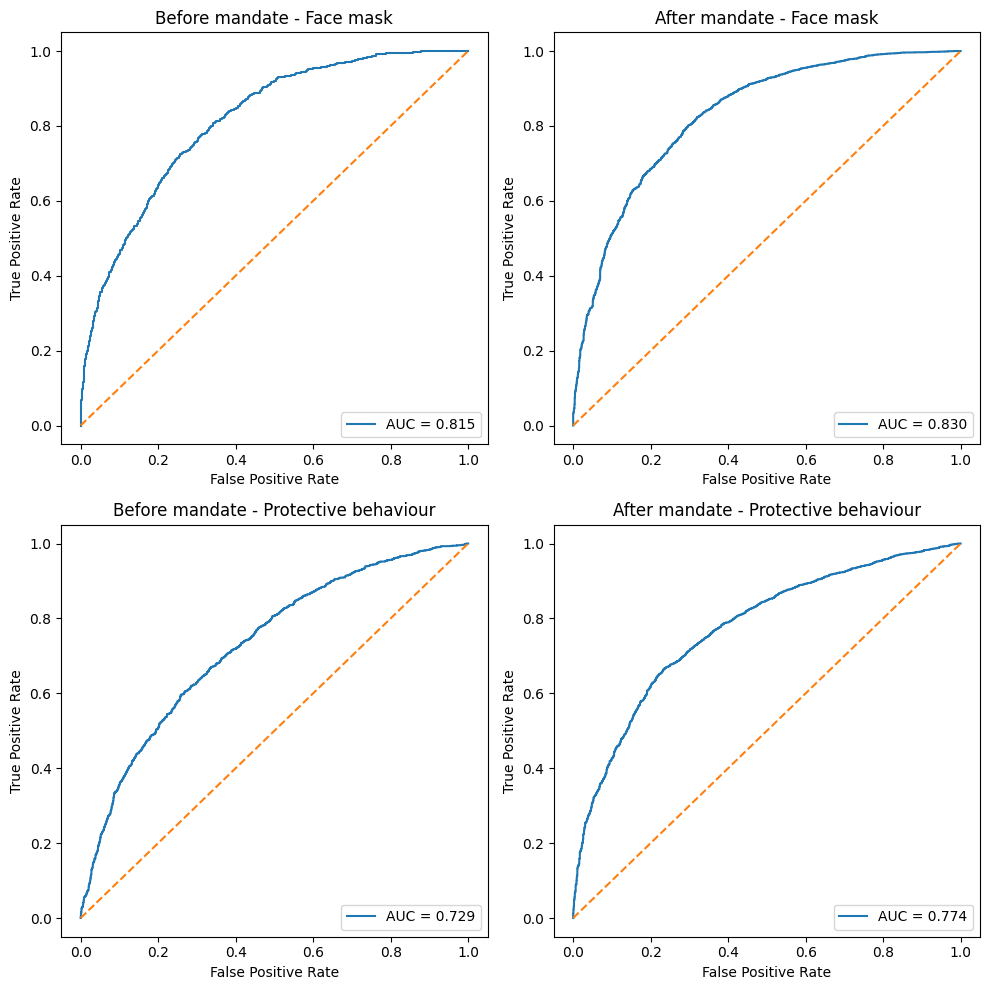

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, task in zip(axes, TASKS.keys()):
    y_test = results[task]["y_test"]
    y_prob = results[task]["y_test_prob"]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    ax.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(TASKS[task])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()


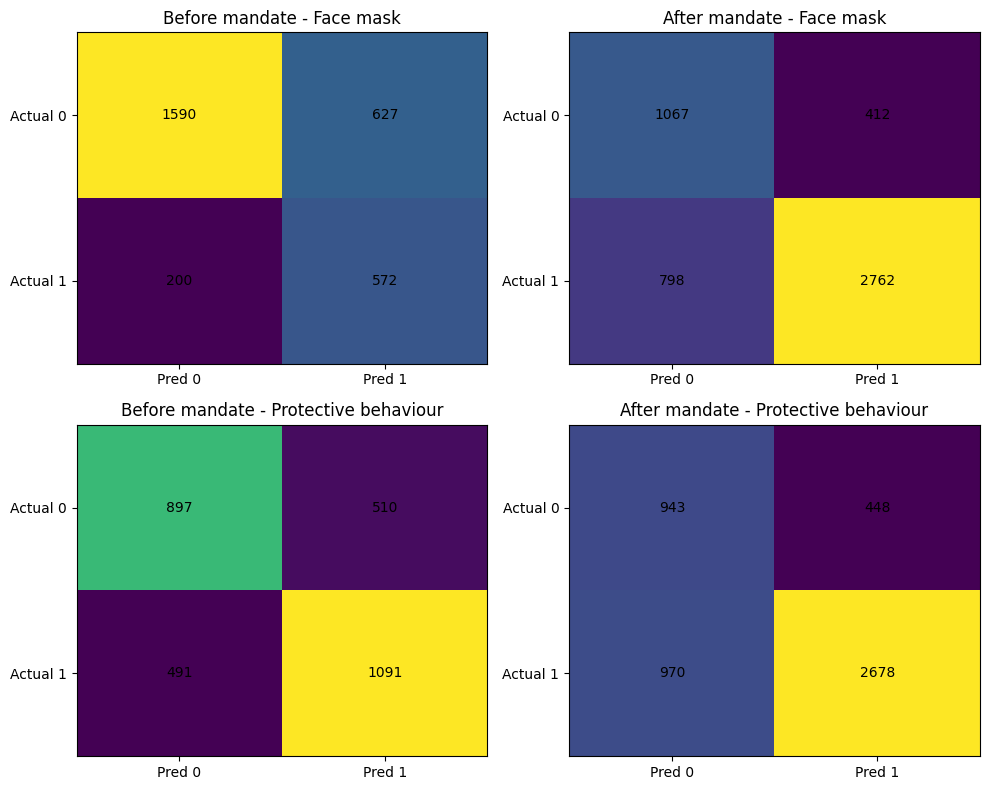

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, task in zip(axes, TASKS.keys()):
    cm = results[task]["cm"]
    ax.imshow(cm, aspect="auto")
    ax.set_title(TASKS[task])
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticklabels(["Actual 0", "Actual 1"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center")

plt.tight_layout()
plt.show()


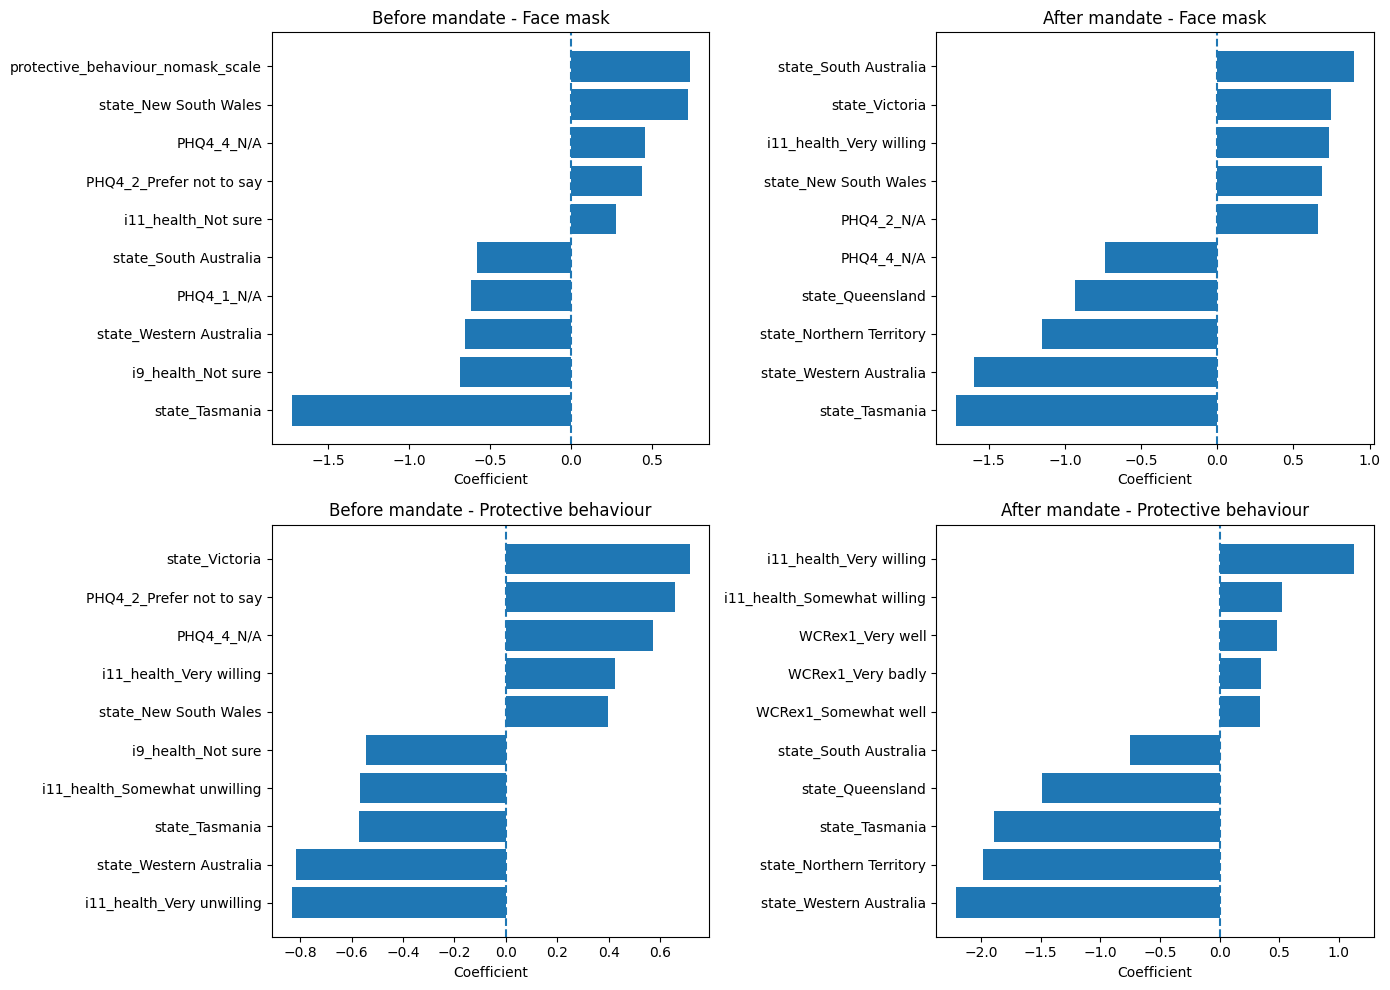

In [5]:
TOP_N = 10

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, task in zip(axes, TASKS.keys()):
    coef_df = results[task]["coef_df"]
    top_pos = coef_df.sort_values("coefficient", ascending=False).head(TOP_N // 2)
    top_neg = coef_df.sort_values("coefficient", ascending=True).head(TOP_N // 2)
    plot_df = pd.concat([top_neg, top_pos]).sort_values("coefficient")

    ax.barh(plot_df["feature"], plot_df["coefficient"])
    ax.axvline(0, linestyle="--")
    ax.set_title(TASKS[task])
    ax.set_xlabel("Coefficient")

plt.tight_layout()
plt.show()


In [6]:
task = "before_mask"
print(task)
display(results[task]["cv_df"].round(4))
display(results[task]["coef_df"].head(20).round(4))
print(results[task]["cm"])


before_mask


,precision,recall,roc_auc,accuracy,f1,fold
0,0.4796,0.7621,0.8188,0.7249,0.5888,1
1,0.4771,0.7439,0.8159,0.7235,0.5814,2
2,0.4861,0.7346,0.8087,0.7307,0.5851,3
3,0.4915,0.7929,0.8333,0.7344,0.6068,4
4,0.4863,0.7735,0.8273,0.7302,0.5971,5


,feature,coefficient,abs_coefficient
12,state_Tasmania,-1.7276,1.7276
6,protective_behaviour_nomask_scale,0.7344,0.7344
8,state_New South Wales,0.7245,0.7245
16,i9_health_Not sure,-0.6863,0.6863
14,state_Western Australia,-0.6543,0.6543
35,PHQ4_1_N/A,-0.6178,0.6178
11,state_South Australia,-0.5827,0.5827
18,employment_status_Not working,-0.5692,0.5692
50,PHQ4_4_N/A,0.4599,0.4599
10,state_Queensland,-0.4537,0.4537


[[1590  627]
 [ 200  572]]


,Task,CV AUC,Test AUC,CV F1,Test F1,CV Accuracy,Test Accuracy,CV Precision,Test Precision,CV Recall,Test Recall
0,Before mandate - Face mask,0.821,0.815,0.592,0.580,0.729,0.723,0.484,0.477,0.761,0.741
1,After mandate - Face mask,0.834,0.830,0.827,0.820,0.769,0.760,0.880,0.870,0.780,0.776
2,Before mandate - Protective behaviour,0.733,0.729,0.692,0.686,0.672,0.665,0.688,0.681,0.696,0.690
3,After mandate - Protective behaviour,0.785,0.774,0.790,0.791,0.720,0.719,0.861,0.857,0.731,0.734


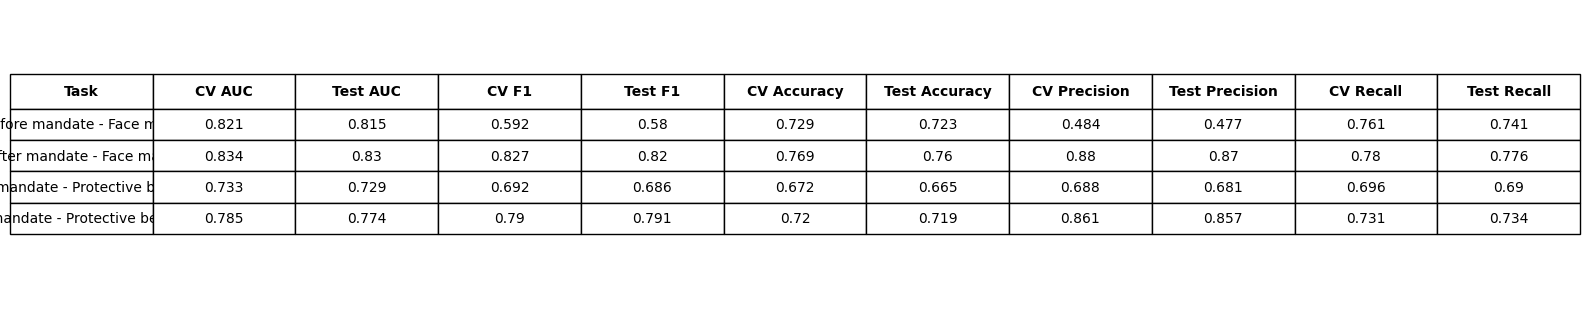

In [7]:
metric_order = ["roc_auc", "f1", "accuracy", "precision", "recall"]
metric_names = {
    "roc_auc": "AUC",
    "f1": "F1",
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
}

task_order = list(TASKS.keys())

cv_tbl = (
    cv_summary_df
    .set_index("task")
    .loc[task_order, ["label"] + metric_order]
    .copy()
)

test_tbl = (
    test_summary_df
    .set_index("task")
    .loc[task_order, metric_order]
    .copy()
)

summary_table = pd.DataFrame({
    "Task": cv_tbl["label"].values
})

for metric in metric_order:
    summary_table[f"CV {metric_names[metric]}"] = cv_tbl[metric].round(3).values
    summary_table[f"Test {metric_names[metric]}"] = test_tbl[metric].round(3).values

display(summary_table)

fig, ax = plt.subplots(figsize=(16, 3.2))
ax.axis("off")

table = ax.table(
    cellText=summary_table.values,
    colLabels=summary_table.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_height(0.12)

plt.tight_layout()
plt.savefig("model_performance_summary_table.png", dpi=300, bbox_inches="tight")
plt.show()
